In [ ]:
import clip
import torch
from PIL import Image
import numpy as np
import gym
from stable_baselines3 import DQN, SAC
from stable_baselines3.common.vec_env import DummyVecEnv
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

In [ ]:
def load_clip_model(device='cpu'):
    clip_model, preprocess = clip.load("ViT-L/14", device=device)
    return clip_model, preprocess

def compute_embeddings(clip_model, preprocess, inputs, device='cpu'):
    with torch.no_grad():
        if isinstance(inputs, list):  
            embeddings = clip_model.encode_text(clip.tokenize(inputs).to(device))
        else:  
            if isinstance(inputs, np.ndarray):  
                inputs = Image.fromarray((inputs * 255).astype(np.uint8))
            img = preprocess(inputs).unsqueeze(0).to(device)
            embeddings = clip_model.encode_image(img)
    return embeddings

def compute_cosine_reward(state, task_description, clip_model, preprocess, device='cpu'):
    img = Image.fromarray((state * 255).astype(np.uint8))  
    image_features = compute_embeddings(clip_model, preprocess, img, device=device)
    text_features = compute_embeddings(clip_model, preprocess, [task_description], device=device)
    reward = torch.cosine_similarity(image_features, text_features).item()
    return reward

def query_vlm_for_preference(clip_model, preprocess, state1, state2, task_description, device='cpu'):
    img1 = Image.fromarray((state1 * 255).astype(np.uint8))
    img2 = Image.fromarray((state2 * 255).astype(np.uint8))

    embedding1 = compute_embeddings(clip_model, preprocess, img1, device=device)
    embedding2 = compute_embeddings(clip_model, preprocess, img2, device=device)
    task_embedding = compute_embeddings(clip_model, preprocess, [task_description], device=device)

    sim1 = torch.cosine_similarity(embedding1, task_embedding).item()
    sim2 = torch.cosine_similarity(embedding2, task_embedding).item()

    return 1 if sim1 > sim2 else 0 

class RewardModel:
    def __init__(self):
        self.model = LogisticRegression()

    def train(self, features, labels):
        self.model.fit(features, labels)

    def predict(self, features):
        return self.model.predict_proba(features)[:, 1]  


class ClipRewardEnv(gym.Env):
    def __init__(self, env, task_description, clip_model, preprocess, preference_buffer, reward_model=None, reward_type='cosine', device='cpu'):
        super(ClipRewardEnv, self).__init__()
        self.env = env
        self.task_description = task_description
        self.clip_model = clip_model
        self.preprocess = preprocess
        self.device = device
        self.preference_buffer = preference_buffer
        self.reward_model = reward_model  
        self.reward_type = reward_type  
        self.observation_space = self.env.observation_space
        self.action_space = self.env.action_space

    def reset(self):
        state, _ = self.env.reset()
        return np.array(state, dtype=np.float32)

    def step(self, action):
        state, _, terminated, truncated, info = self.env.step(action)

        if self.reward_type == 'preference' and self.reward_model is not None and len(self.preference_buffer) > 100:
            embedding = compute_embeddings(self.clip_model, self.preprocess, state, device=self.device).cpu().numpy()
            reward = self.reward_model.predict(embedding.reshape(1, -1))[0]
        else:  
            reward = compute_cosine_reward(state, self.task_description, self.clip_model, self.preprocess, device=self.device)

       
        if np.random.rand() < 0.1:  
            state2 = self.env.observation_space.sample()  
            preference = query_vlm_for_preference(self.clip_model, self.preprocess, state, state2, self.task_description, self.device)
            self.preference_buffer.append((state, state2, preference))

        done = terminated or truncated
        return np.array(state, dtype=np.float32), reward, done, info



def train_reward_model(reward_model, preference_buffer, clip_model, preprocess, device='cpu'):
    features = []
    labels = []

    for state1, state2, preference in preference_buffer:
        embedding1 = compute_embeddings(clip_model, preprocess, state1, device=device).cpu().numpy().flatten()
        embedding2 = compute_embeddings(clip_model, preprocess, state2, device=device).cpu().numpy().flatten()
        
        
        feature = (embedding1 - embedding2).reshape(-1)
        features.append(feature)
        labels.append(preference)

  
    features = np.array(features)
    labels = np.array(labels)

    reward_model.train(features, labels)



c:\Users\Asus\anaconda3\envs\rl\lib\site-packages\torchvision\io\image.py:13: UserWarning: Failed to load image Python extension: [WinError 127] The specified procedure could not be found
  warn(f"Failed to load image Python extension: {e}")


In [ ]:
clip_model, preprocess = load_clip_model(device)

# task test
task_description = "pole vertically upright on top of the cart"

# Cartpole env
env = gym.make("CartPole-v1")
preference_buffer = []


reward_model = RewardModel()  
clip_reward_env = ClipRewardEnv(env, task_description, clip_model, preprocess, preference_buffer, reward_model, device=device)
vec_env = DummyVecEnv([lambda: clip_reward_env])


model = DQN("MlpPolicy", vec_env, verbose=1)

# Training
total_timesteps = 10000 
for step in range(0, total_timesteps, 200):
    model.learn(total_timesteps=200, reset_num_timesteps=False)
    if len(preference_buffer) > 100:
        train_reward_model(reward_model, preference_buffer, clip_model, preprocess, device=device)

print("Training complete!")


c:\Users\Asus\anaconda3\envs\rl\lib\site-packages\stable_baselines3\common\vec_env\patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


Using cpu device


c:\Users\Asus\anaconda3\envs\rl\lib\site-packages\gym\utils\passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):
C:\Users\Asus\AppData\Local\Temp\ipykernel_14832\2526134331.py:39: RuntimeWarning: overflow encountered in multiply
  img2 = Image.fromarray((state2 * 255).astype(np.uint8))
C:\Users\Asus\AppData\Local\Temp\ipykernel_14832\2526134331.py:39: RuntimeWarning: invalid value encountered in cast
  img2 = Image.fromarray((state2 * 255).astype(np.uint8))


----------------------------------
| rollout/            |          |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 4        |
|    fps              | 0        |
|    time_elapsed     | 126      |
|    total_timesteps  | 114      |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.0267   |
|    n_updates        | 3        |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 8        |
|    fps              | 0        |
|    time_elapsed     | 167      |
|    total_timesteps  | 152      |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.0301   |
|    n_updates        | 12       |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rat

C:\Users\Asus\AppData\Local\Temp\ipykernel_14832\2526134331.py:23: RuntimeWarning: overflow encountered in multiply
  inputs = Image.fromarray((inputs * 255).astype(np.uint8))
C:\Users\Asus\AppData\Local\Temp\ipykernel_14832\2526134331.py:23: RuntimeWarning: invalid value encountered in cast
  inputs = Image.fromarray((inputs * 255).astype(np.uint8))
C:\Users\Asus\AppData\Local\Temp\ipykernel_14832\2526134331.py:39: RuntimeWarning: overflow encountered in multiply
  img2 = Image.fromarray((state2 * 255).astype(np.uint8))
C:\Users\Asus\AppData\Local\Temp\ipykernel_14832\2526134331.py:39: RuntimeWarning: invalid value encountered in cast
  img2 = Image.fromarray((state2 * 255).astype(np.uint8))


...

----------------------------------
| rollout/            |          |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 496      |
|    fps              | 0        |
|    time_elapsed     | 51       |
|    total_timesteps  | 4845     |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.00049  |
|    n_updates        | 1186     |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 500      |
|    fps              | 0        |
|    time_elapsed     | 97       |
|    total_timesteps  | 4886     |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.000252 |
|    n_updates        | 1196     |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rat

C:\Users\Asus\AppData\Local\Temp\ipykernel_14832\2526134331.py:23: RuntimeWarning: overflow encountered in multiply
  inputs = Image.fromarray((inputs * 255).astype(np.uint8))
C:\Users\Asus\AppData\Local\Temp\ipykernel_14832\2526134331.py:23: RuntimeWarning: invalid value encountered in cast
  inputs = Image.fromarray((inputs * 255).astype(np.uint8))
C:\Users\Asus\AppData\Local\Temp\ipykernel_14832\2526134331.py:39: RuntimeWarning: overflow encountered in multiply
  img2 = Image.fromarray((state2 * 255).astype(np.uint8))
C:\Users\Asus\AppData\Local\Temp\ipykernel_14832\2526134331.py:39: RuntimeWarning: invalid value encountered in cast
  img2 = Image.fromarray((state2 * 255).astype(np.uint8))


----------------------------------
| rollout/            |          |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 516      |
|    fps              | 0        |
|    time_elapsed     | 40       |
|    total_timesteps  | 5039     |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.000513 |
|    n_updates        | 1234     |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 520      |
|    fps              | 0        |
|    time_elapsed     | 84       |
|    total_timesteps  | 5077     |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.000708 |
|    n_updates        | 1244     |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rat

C:\Users\Asus\AppData\Local\Temp\ipykernel_14832\2526134331.py:23: RuntimeWarning: overflow encountered in multiply
  inputs = Image.fromarray((inputs * 255).astype(np.uint8))
C:\Users\Asus\AppData\Local\Temp\ipykernel_14832\2526134331.py:23: RuntimeWarning: invalid value encountered in cast
  inputs = Image.fromarray((inputs * 255).astype(np.uint8))
C:\Users\Asus\AppData\Local\Temp\ipykernel_14832\2526134331.py:39: RuntimeWarning: overflow encountered in multiply
  img2 = Image.fromarray((state2 * 255).astype(np.uint8))
C:\Users\Asus\AppData\Local\Temp\ipykernel_14832\2526134331.py:39: RuntimeWarning: invalid value encountered in cast
  img2 = Image.fromarray((state2 * 255).astype(np.uint8))


KeyboardInterrupt: 

C:\Users\Asus\AppData\Local\Temp\ipykernel_14832\2526134331.py:39: RuntimeWarning: overflow encountered in multiply
  img2 = Image.fromarray((state2 * 255).astype(np.uint8))
C:\Users\Asus\AppData\Local\Temp\ipykernel_14832\2526134331.py:39: RuntimeWarning: invalid value encountered in cast
  img2 = Image.fromarray((state2 * 255).astype(np.uint8))


Min Pole Angle: -0.049436479806900024, Max Pole Angle: 0.20930498838424683


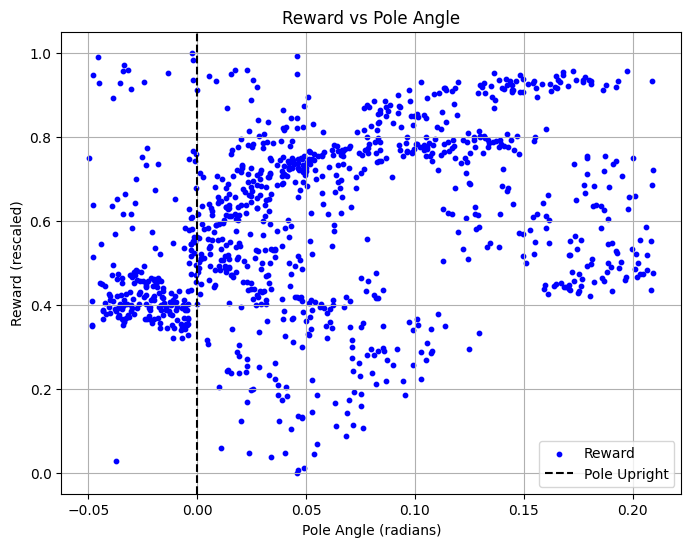

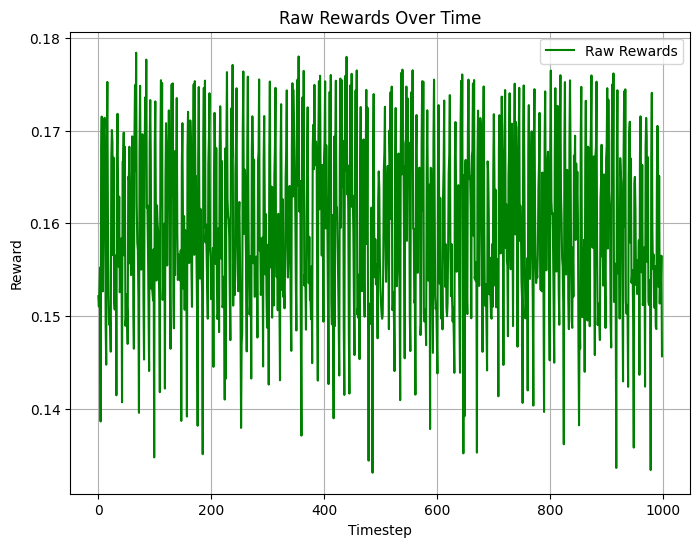

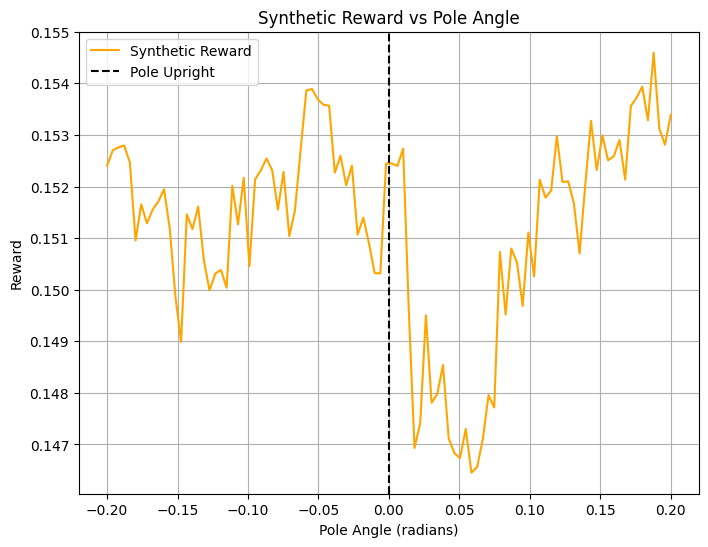

In [ ]:

pole_angles = []
rewards = []

# Testing
obs = vec_env.reset()
for _ in range(1000):  
    action, _ = model.predict(obs)  
    obs, reward, done, info = vec_env.step(action)

   
    pole_angle = float(obs[0][2]) 
    pole_angles.append(pole_angle)

  
    rewards.append(float(reward[0]))  
    if done[0]: 
        obs = vec_env.reset()


pole_angles = np.array(pole_angles)
rewards = np.array(rewards)


normalized_rewards = (rewards - rewards.min()) / (rewards.max() - rewards.min())


print(f"Min Pole Angle: {pole_angles.min()}, Max Pole Angle: {pole_angles.max()}")

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(pole_angles, normalized_rewards, s=10, alpha=1.0, color='blue', label='Reward')
plt.axvline(x=0, color='black', linestyle='--', label='Pole Upright')
plt.xlabel("Pole Angle (radians)")
plt.ylabel("Reward (rescaled)")
plt.title("Reward vs Pole Angle")
plt.legend()
plt.grid()
plt.show()

# Plot to observe raw reward
plt.figure(figsize=(8, 6))
plt.plot(rewards, color='green', label='Raw Rewards')
plt.xlabel("Timestep")
plt.ylabel("Reward")
plt.title("Raw Rewards Over Time")
plt.legend()
plt.grid()
plt.show()

# Synthetic Analysis: Reward vs Pole Angle (manually generated state)
pole_angles = np.linspace(-0.2, 0.2, num=100)  
synthetic_rewards = []


for angle in pole_angles:
    synthetic_state = np.array([0.0, 0.0, angle, 0.0]) 
    reward = compute_cosine_reward(
        synthetic_state,
        task_description="pole vertically upright on top of the cart",
        clip_model=clip_model,
        preprocess=preprocess,
        device=device
    )
    synthetic_rewards.append(reward)


plt.figure(figsize=(8, 6))
plt.plot(pole_angles, synthetic_rewards, color='orange', label='Synthetic Reward')
plt.axvline(x=0, color='black', linestyle='--', label='Pole Upright')
plt.xlabel("Pole Angle (radians)")
plt.ylabel("Reward")
plt.title("Synthetic Reward vs Pole Angle")
plt.legend()
plt.grid()
plt.show()


In [ ]:
# Save trained model
model.save("cartpole_dqn_pref")
print("Model saved successfully!")

Model saved successfully!
